# 03 - Shallow Networks

**AI sin humo** - Notas personales para entender deep learning desde cero.

Una shallow network es una red con **una sola hidden layer**. Acá vemos cómo al combinar perceptrones con activaciones no lineales podemos resolver problemas que un solo perceptrón no puede (como XOR), cómo las activaciones particionan el espacio de inputs, y por qué una shallow network puede aproximar **cualquier función continua**.

---

## Contenido

1. [¿Por qué combinar perceptrones?](#por-que-combinar)
2. [El problema con combinar sin activación](#sin-activacion)
3. [Activaciones: la clave de todo](#activaciones)
4. [Threshold vs ReLU vs Sigmoid: ¿cuál usar?](#comparacion-activaciones)
5. [Arquitectura: por qué en paralelo y no secuencial](#arquitectura)
6. [Paso a paso: cómo funciona una shallow network](#paso-a-paso)
7. [Regiones lineales: cómo se particiona el espacio](#regiones-lineales)
8. [Resolver XOR con 2 hidden units](#resolver-xor)
9. [Aproximador universal](#aproximador-universal)
10. [Múltiples inputs y outputs](#multiples-io)

In [1]:
import numpy as np
import matplotlib.pyplot as plt

---

<a id='por-que-combinar'></a>
## 1. ¿Por qué combinar perceptrones?

Ya vimos que un perceptrón solo puede resolver problemas linealmente separables. Si queremos resolver algo como XOR, necesitamos **combinar** perceptrones.

La idea es: tenemos dos (o más) perceptrones, cada uno recibe el input inicial. Cada uno genera su propia clasificación o valor. Después los combinamos para obtener el resultado final.

![Combinación de perceptrones para XOR](../ai_notas/AI%20notas/image%2010.png)

Pero hay un detalle crucial: **¿los perceptrones tienen activación o no?**

---

<a id='sin-activacion'></a>
## 2. El problema con combinar sin activación

Si combinamos dos perceptrones **sin activación** (solo lineales), lo que obtenemos es... **otra función lineal**. Combinar dos lineales da una lineal. Entonces tampoco resolveríamos XOR.

Esto es un punto fundamental:

> **Sin importar cuántas funciones lineales combines, el resultado siempre es lineal.** Es como mezclar distintos tonos de blanco: siempre te queda blanco.

Por eso necesitamos la activación: para romper la linealidad.

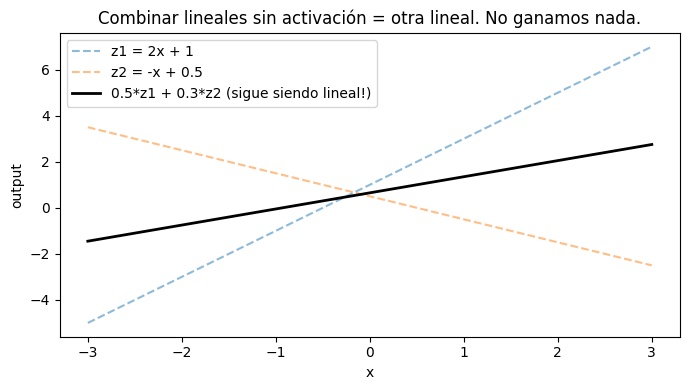

In [2]:
# Demonstrate: combining linear functions gives a linear function
x = np.linspace(-3, 3, 200)

# Two linear functions
z1 = 2 * x + 1     # first "perceptron"
z2 = -1 * x + 0.5  # second "perceptron"

# Combination (weighted sum) is still linear!
combined = 0.5 * z1 + 0.3 * z2

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(x, z1, '--', alpha=0.5, label='z1 = 2x + 1')
ax.plot(x, z2, '--', alpha=0.5, label='z2 = -x + 0.5')
ax.plot(x, combined, 'k-', lw=2, label='0.5*z1 + 0.3*z2 (sigue siendo lineal!)')
ax.set_xlabel('x')
ax.set_ylabel('output')
ax.set_title('Combinar lineales sin activación = otra lineal. No ganamos nada.')
ax.legend()
plt.tight_layout()
plt.show()

---

<a id='activaciones'></a>
## 3. Activaciones: la clave de todo

**Hay que recordar algo fundamental que aplica a todo lo que vamos a ver de acá en adelante**:

> **Todo lo que queremos hacer SIEMPRE es particionar el espacio de inputs y asignarle valores a cada región.** Esos valores representan algo: una decisión (0 o 1), una probabilidad, un valor numérico. Mientras más particionemos, más detallado y expresivo es el modelo.

La forma de particionar el espacio de inputs para asignarle valores distintos es **agregándole no-linealidades (activaciones) a las neuronas**. La activación particiona el espacio y, al combinar las neuronas después, nos da flexibilidad para que cada partición tenga valores o comportamientos distintos.

**Con activación**: incluso usando un threshold simple ya podemos resolver XOR. Cada perceptrón con activación es una función **no lineal**, entonces al combinar dos funciones no lineales, el resultado es algo más complejo que lo puede resolver.

![Combinación con activación](../ai_notas/AI%20notas/image%2011.png)

En este ejemplo con XOR, los pesos y sesgos son:
- Hidden unit 1: $w_1 = (1,1)$, $b_1 = -0.5$ (detecta "al menos uno es 1", tipo OR)
- Hidden unit 2: $w_2 = (1,1)$, $b_2 = -1.5$ (detecta "ambos son 1", tipo AND)
- Output: $w_{out} = (1, -1)$, $b_{out} = -0.5$

Lo importante es entender que al agregar no-linealidad a las hidden units, estamos **partiendo el espacio** y quebrándolo, dándole potenciales formas que hacen a la función más expresiva.

Nota: que se use el threshold como activación no implica que la salida final del modelo siempre sea binaria. Al combinar las salidas, puede dar otros valores.

---

<a id='comparacion-activaciones'></a>
## 4. Threshold vs ReLU vs Sigmoid: ¿cuál usar?

Queremos activaciones que sean:
- **Diferenciables** (o que se puedan aproximar): porque necesitamos calcular gradientes para entrenar
- **Expresivas**: binarias se quedan cortas, pierden información
- **Smooth** (suaves): las binarias siempre generan saltos. No hay rampas ni inclinaciones en el resultado final. Y no es que se pueda suavizar poniendo una sigmoide al final, porque eso transformaría todo en sigmoide. Tiene que hacerse en **cada unit**.

![Threshold genera saltos, no es smooth](../ai_notas/AI%20notas/image%2012.png)

### Threshold (step)
- **No es diferenciable** → no podemos calcular gradientes → no sirve para entrenar con gradient descent
- **Es binaria** → pierde información en cada neurona
- **No es smooth** → siempre se mueve de a saltos
- **Dejamos de lado esta activación** de acá en adelante

### ReLU (Rectified Linear Unit)
- $\text{ReLU}(z) = \max(0, z)$
- Simple: si es negativo, cero. Si es positivo, dejarlo igual
- Casi diferenciable (no lo es en z=0 pero se estima sin problemas)
- Genera **regiones lineales** continuas → muy útil
- **La más usada en deep learning moderno**

![ReLU](../ai_notas/AI%20notas/image%2013.png)

### Sigmoid
- Deja valores entre 0 y 1 con forma de S
- Completamente smooth y diferenciable
- Genera curvas suaves en vez de regiones lineales
- Tiene problemas de vanishing gradients en redes profundas (lo veremos más adelante)

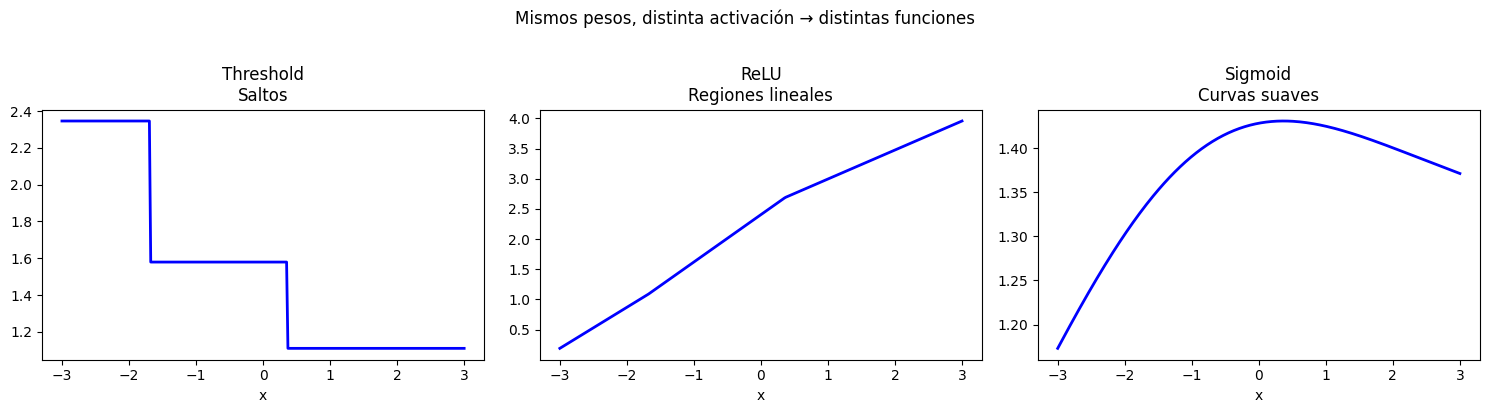

In [3]:
def relu(z):
    return np.maximum(0, z)


# Compare what kind of functions each activation produces
# when we combine 3 units with random weights
np.random.seed(42)
x = np.linspace(-3, 3, 300)
n_units = 3

w_hidden = np.random.randn(n_units)
b_hidden = np.random.randn(n_units)
w_out = np.random.randn(n_units)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, act_fn, name in [(axes[0], lambda z: np.where(z >= 0, 1, 0), 'Threshold'),
                          (axes[1], relu, 'ReLU'),
                          (axes[2], lambda z: 1/(1+np.exp(-z)), 'Sigmoid')]:
    output = np.zeros_like(x)
    for i in range(n_units):
        z = w_hidden[i] * x + b_hidden[i]
        h = act_fn(z)
        output += w_out[i] * h
    
    ax.plot(x, output, 'b-', lw=2)
    ax.set_title(f'{name}\n{"Saltos" if name=="Threshold" else "Regiones lineales" if name=="ReLU" else "Curvas suaves"}')
    ax.set_xlabel('x')

plt.suptitle('Mismos pesos, distinta activación → distintas funciones', y=1.02)
plt.tight_layout()
plt.show()

---

<a id='arquitectura'></a>
## 5. Arquitectura: por qué en paralelo y no secuencial

Una **shallow network** tiene solo 1 hidden layer. La arquitectura es:

```
input layer (datos de entrada) → hidden layer (múltiples neuronas) → output layer (combinación lineal final)
```

![Arquitectura shallow network](../ai_notas/AI%20notas/image%2014.png)

### Vocabulario

- **Neurona / Hidden unit**: una unidad en la hidden layer (función lineal + activación no lineal)
- **Layer / Capa**: conjunto de neuronas que se procesan **en paralelo**

### ¿Por qué en paralelo y no secuencial?

Podríamos poner los perceptrones uno detrás del otro:

```
x → [Perceptrón 1] → ReLU → [Perceptrón 2] → ReLU → [Perceptrón 3] → ReLU → y
```

Pero en este caso secuencial se va delimitando el espacio **JERÁRQUICAMENTE**: cada perceptrón va "matando" zonas y solo trabajamos para hacer particiones consecutivas **solo en el rango que quedó vivo**, no en todo el espacio.

Si queremos usar **todo el espacio** y cortarlo de distintas maneras, **no jerárquicamente**, podemos hacer una **CAPA** de neuronas con activación (en paralelo) y después simplemente combinarlas linealmente:

```
x ──► [ w₁·x + b₁ ] ──► ReLU ──► h₁ ┐
   ──► [ w₂·x + b₂ ] ──► ReLU ──► h₂ ├─► (combinación lineal) ──► y
   ──► [ w₃·x + b₃ ] ──► ReLU ──► h₃ ┘
```

Cada neurona corta el espacio de forma **independiente**, y después al combinarlas se crean regiones más complejas. Esto da mucha más flexibilidad.

![Shallow network diagram](../ai_notas/AI%20notas/image%2015.png)

---

<a id='paso-a-paso'></a>
## 6. Paso a paso: cómo funciona una shallow network

Veamos con 3 hidden units y ReLU qué pasa en cada etapa:

1. **Pre-activación**: son las funciones lineales de cada hidden unit (cada neurona en la hidden layer). Acá son 3: $z_i = w_i \cdot x + b_i$
2. **Activación**: es pasarle el ReLU a las pre-activaciones y generar el output de cada hidden unit: $h_i = \text{ReLU}(z_i)$
3. **Escalado por pesos**: es la salida de cada hidden unit pesada por el weight correspondiente hacia el output: $w_{\text{out},i} \cdot h_i$
4. **Salida final**: es la suma de los outputs de las hidden units escalados + el bias del output: $y = \sum_i w_{\text{out},i} \cdot h_i + b_{\text{out}}$

![Paso a paso de una shallow network](../ai_notas/AI%20notas/image%2016.png)

In [4]:
class ShallowNetwork:
    """Shallow network with 1 hidden layer and ReLU activation."""
    
    def __init__(self, n_input, n_hidden, n_output):
        # Hidden layer parameters
        self.w_hidden = np.random.randn(n_hidden, n_input) * 0.5
        self.b_hidden = np.random.randn(n_hidden) * 0.5
        # Output layer parameters
        self.w_out = np.random.randn(n_output, n_hidden) * 0.5
        self.b_out = np.random.randn(n_output) * 0.5
    
    def forward(self, x):
        # Step 1: pre-activation (linear)
        z = self.w_hidden @ x + self.b_hidden
        # Step 2: activation (ReLU)
        h = relu(z)
        # Steps 3-4: output = weighted sum of hidden outputs + bias
        y = self.w_out @ h + self.b_out
        return y, h, z

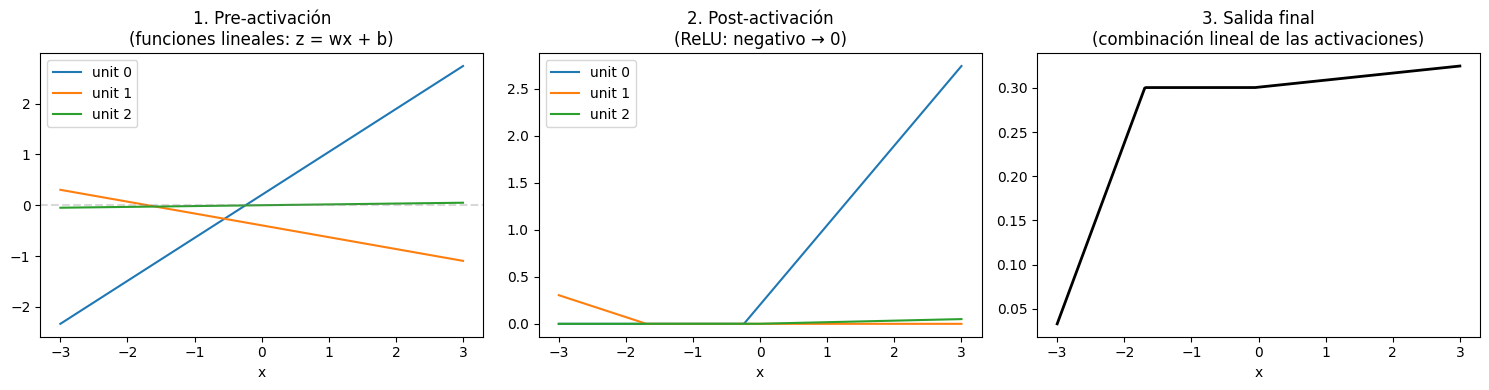

In [5]:
# Visualize what happens at each step
np.random.seed(7)
net = ShallowNetwork(n_input=1, n_hidden=3, n_output=1)

x_range = np.linspace(-3, 3, 300)
outputs, hiddens, pre_acts = [], [], []

for xi in x_range:
    y, h, z = net.forward(np.array([xi]))
    outputs.append(y[0])
    hiddens.append(h)
    pre_acts.append(z)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Pre-activations: straight lines
for i in range(3):
    axes[0].plot(x_range, [z[i] for z in pre_acts], label=f'unit {i}')
axes[0].set_title('1. Pre-activación\n(funciones lineales: z = wx + b)')
axes[0].axhline(y=0, color='gray', linestyle='--', alpha=0.3)
axes[0].legend()
axes[0].set_xlabel('x')

# Activations: ReLU clips negatives to 0
for i in range(3):
    axes[1].plot(x_range, [h[i] for h in hiddens], label=f'unit {i}')
axes[1].set_title('2. Post-activación\n(ReLU: negativo → 0)')
axes[1].legend()
axes[1].set_xlabel('x')

# Final output: combination
axes[2].plot(x_range, outputs, 'k-', lw=2)
axes[2].set_title('3. Salida final\n(combinación lineal de las activaciones)')
axes[2].set_xlabel('x')

plt.tight_layout()
plt.show()

---

<a id='regiones-lineales'></a>
## 7. Regiones lineales: cómo se particiona el espacio

Como vimos muchas veces, la clave es **particionar el espacio en muchas regiones**. Con ReLU podemos particionarlo en muchas **regiones lineales** que sean continuas, donde va cambiando la pendiente. Es como una función hecha de pedazos de rectas pegados.

Ya vimos que:
- Con **threshold** no se crean regiones lineales continuas sino saltos (steps)
- Con **sigmoid** no se crean regiones lineales sino algo más continuo, como curvas suaves
- Con **ReLU** se crean regiones lineales continuas donde cambia la pendiente → perfecto

![Comparación de activaciones y regiones](../ai_notas/AI%20notas/image%2017.png)

### ¿Cuántas regiones se crean?

Cada partición está dada por una hidden unit porque es la que hace la activación (la no-linealidad). Al generar varios cortes y después combinarlos, nos quedan varias regiones lineales.

¿Cuántas? Depende de dos cosas:
- **Cantidad de neuronas** en la hidden layer ($n$)
- **Dimensión del input** ($D$)

Para **input 1D** (un solo x), tenemos como máximo $n + 1$ regiones lineales. Cada hidden unit aporta un corte en el espacio y al combinarlos se crean $n + 1$ regiones (puede ser menos si los cortes caen en el mismo lugar).

En **inputs 2D**, se corta con un hiperplano, y si hay más espacio, se generan más particiones.

![Regiones lineales por dimensión](../ai_notas/AI%20notas/image%2018.png)

Ejemplos:
1. Con input 1D, 1 hidden unit → divide el eje en **2 regiones** lineales
2. Con input 2D, 2 hidden units → pueden dividir el plano con dos líneas para crear hasta **4 regiones**
3. Con input 3D, 3 hidden units → pueden dividir el espacio con tres planos para crear hasta **8 regiones**

**Regla general**: Input dimensión $D$ y $D$ hidden units → hasta $2^D$ regiones lineales

![Más regiones](../ai_notas/AI%20notas/image%2019.png)

![Ejemplo visual de regiones](../ai_notas/AI%20notas/image%2020.png)

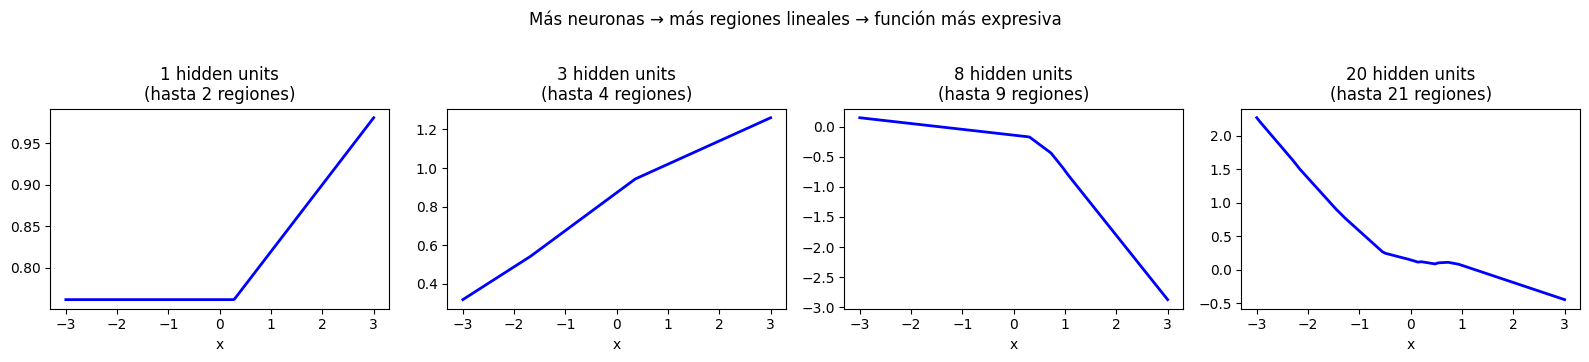

In [6]:
# Demonstrate: more hidden units = more linear regions = more expressive
fig, axes = plt.subplots(1, 4, figsize=(16, 3.5))
x_range = np.linspace(-3, 3, 300)

for ax, n_hidden in zip(axes, [1, 3, 8, 20]):
    np.random.seed(42)
    net = ShallowNetwork(n_input=1, n_hidden=n_hidden, n_output=1)
    outputs = [net.forward(np.array([xi]))[0][0] for xi in x_range]
    
    ax.plot(x_range, outputs, 'b-', lw=2)
    ax.set_title(f'{n_hidden} hidden units\n(hasta {n_hidden+1} regiones)')
    ax.set_xlabel('x')

plt.suptitle('Más neuronas → más regiones lineales → función más expresiva', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---

<a id='resolver-xor'></a>
## 8. Resolver XOR con 2 hidden units

Con solo 2 hidden units ya podemos resolver XOR, algo que un perceptrón solo no puede.

### Con ReLU (2 hidden units)

![XOR con ReLU](../ai_notas/AI%20notas/image%2021.png)

### Con Sigmoid (2 hidden units)

![XOR con Sigmoid](../ai_notas/AI%20notas/image%2022.png)

Acá no estamos aplicando función de activación final sino que estamos dejando el output de la red crudo. Si quisiéramos clasificar, podríamos ponerle un threshold al final y que lo transforme en 0 o 1.

In [7]:
# Manual XOR solution with 2 hidden units + ReLU
X_xor = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_xor = np.array([0, 1, 1, 0])

# Manually set weights that solve XOR
w_hidden = np.array([[1, 1],     # unit 1: w = (1,1), detects "at least one is 1"
                      [1, 1]])    # unit 2: w = (1,1), detects "both are 1"
b_hidden = np.array([-0.5, -1.5])  # unit 1: b=-0.5 (OR-like), unit 2: b=-1.5 (AND-like)

w_out = np.array([[1, -2]])  # combine: take OR result minus 2x AND result
b_out = np.array([0.0])

print("Resolviendo XOR manualmente con 2 hidden units + ReLU:\n")
for xi, yi in zip(X_xor, y_xor):
    z = w_hidden @ xi + b_hidden
    h = relu(z)
    output = w_out @ h + b_out
    print(f"  Input: {xi}")
    print(f"    → pre-activación z = {z}")
    print(f"    → activación h(ReLU) = {h}")
    print(f"    → output = {output[0]:.1f} (esperado: {yi})")
    print()

Resolviendo XOR manualmente con 2 hidden units + ReLU:

  Input: [0 0]
    → pre-activación z = [-0.5 -1.5]
    → activación h(ReLU) = [0. 0.]
    → output = 0.0 (esperado: 0)

  Input: [0 1]
    → pre-activación z = [ 0.5 -0.5]
    → activación h(ReLU) = [0.5 0. ]
    → output = 0.5 (esperado: 1)

  Input: [1 0]
    → pre-activación z = [ 0.5 -0.5]
    → activación h(ReLU) = [0.5 0. ]
    → output = 0.5 (esperado: 1)

  Input: [1 1]
    → pre-activación z = [1.5 0.5]
    → activación h(ReLU) = [1.5 0.5]
    → output = 0.5 (esperado: 0)



---

<a id='aproximador-universal'></a>
## 9. Aproximador universal

Este es uno de los teoremas más importantes en redes neuronales:

> **Cualquier función continua** que queramos, no importa qué tan compleja sea, puede ser aproximada **arbitrariamente bien** por una shallow network de solo 1 hidden layer, si tiene las suficientes neuronas (hidden units) y una activación no lineal.

Nota: no se incluye threshold porque no es una activación continua y entonces no garantiza una aproximación uniforme. No lo puede aproximar suavemente.

Dicho más simple:

1. Vos querés una función que haga "algo" con los inputs: prediga un precio, una probabilidad, una clase, etc.
2. Esa función puede tener curvas, quiebres, subidas y bajadas.
3. El teorema te dice: **con una sola capa oculta**, pero **muchas neuronas**, ya podés construir una función que **se parezca tanto como quieras** a la original.
4. Lo único que necesitás es que la activación **rompa la linealidad**. Por eso no sirve si todo es lineal.

Una función continua es la que podés dibujar sin levantar el lápiz del papel (sin saltos ni discontinuidades).

### Ejemplo: clasificar puntos rodeados por otra clase

Podemos resolver problemas más complejos, como clasificar puntos que estén rodeados por puntos de otra clase:

![Problema complejo de clasificación](../ai_notas/AI%20notas/image%2023.png)

Con 8 hidden units y ReLU ya se resuelve:

![Solución con 8 hidden units](../ai_notas/AI%20notas/image%2024.png)

A medida que aumentamos la cantidad de hidden units, se torna más flexible para representar la función que queramos.

### Entonces, ¿para qué necesitamos deep networks?

Si una shallow network puede aproximar cualquier cosa, ¿por qué complicarnos con más capas? Porque para funciones complejas, una shallow network necesita una cantidad **ENORME** de neuronas. Las deep networks logran lo mismo con **muchos menos parámetros**. Es una cuestión de eficiencia computacional, que vemos en el siguiente notebook.

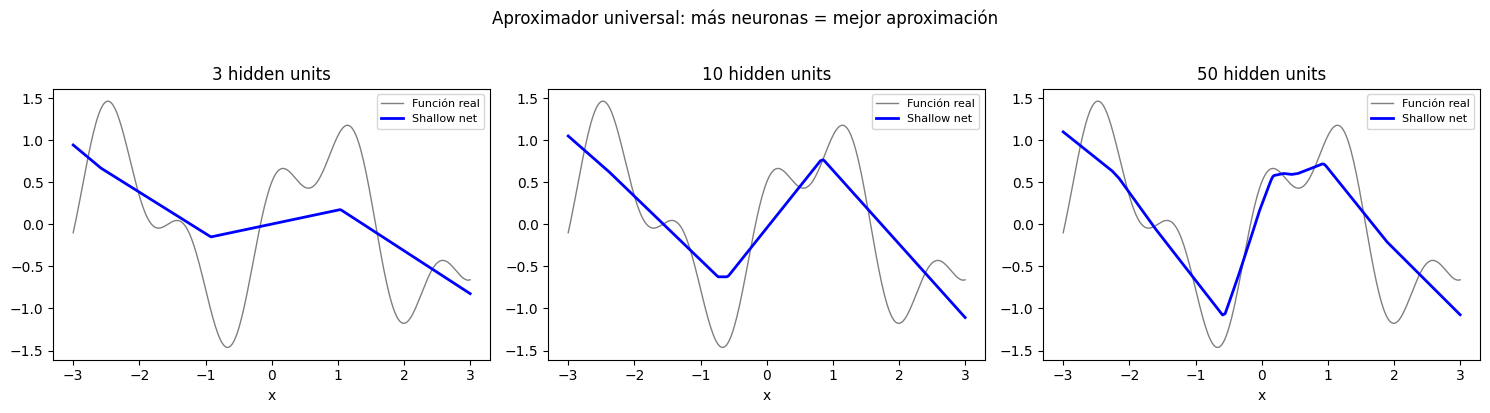

In [8]:
# Demonstrate the universal approximation theorem:
# A shallow network can approximate any continuous function

def target_function(x):
    """A complex wavy function we want to approximate."""
    return np.sin(2 * x) + 0.5 * np.cos(5 * x)


def train_shallow(n_hidden, n_steps=3000, lr=0.01):
    """Train a shallow network to approximate the target function."""
    # Initialize parameters
    w1 = np.random.randn(n_hidden, 1) * 0.5
    b1 = np.random.randn(n_hidden) * 0.5
    w2 = np.random.randn(1, n_hidden) * 0.5
    b2 = np.zeros(1)
    
    # Training data
    x_train = np.linspace(-3, 3, 50).reshape(-1, 1)
    y_train = target_function(x_train)
    
    for step in range(n_steps):
        # Forward
        z1 = x_train @ w1.T + b1
        h1 = np.maximum(0, z1)  # ReLU
        y_pred = h1 @ w2.T + b2
        
        # Backward (MSE gradients)
        error = y_pred - y_train
        d_w2 = error.T @ h1 / len(x_train)
        d_b2 = error.mean(axis=0)
        d_h1 = error @ w2
        d_z1 = d_h1 * (z1 > 0)
        d_w1 = d_z1.T @ x_train / len(x_train)
        d_b1 = d_z1.mean(axis=0)
        
        # Update
        w2 -= lr * d_w2
        b2 -= lr * d_b2
        w1 -= lr * d_w1
        b1 -= lr * d_b1
    
    return w1, b1, w2, b2


# Compare: more hidden units = better approximation
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
x_plot = np.linspace(-3, 3, 300).reshape(-1, 1)
y_true = target_function(x_plot)

for ax, n_h in zip(axes, [3, 10, 50]):
    np.random.seed(42)
    w1, b1, w2, b2 = train_shallow(n_h, n_steps=3000, lr=0.01)
    
    z1 = x_plot @ w1.T + b1
    h1 = np.maximum(0, z1)
    y_pred = h1 @ w2.T + b2
    
    ax.plot(x_plot, y_true, 'k-', lw=1, alpha=0.5, label='Función real')
    ax.plot(x_plot, y_pred, 'b-', lw=2, label='Shallow net')
    ax.set_title(f'{n_h} hidden units')
    ax.legend(fontsize=8)
    ax.set_xlabel('x')

plt.suptitle('Aproximador universal: más neuronas = mejor aproximación', y=1.02)
plt.tight_layout()
plt.show()

---

<a id='multiples-io'></a>
## 10. Múltiples inputs y outputs

Podemos tener muchos inputs y muchos outputs.

![Red con múltiples I/O](../ai_notas/AI%20notas/image%2015.png)

Los outputs pueden representar **cualquier cosa** que queramos, y podemos ponernos creativos con eso:
- En un **robot**: cada output puede representar cuánto se debería mover el brazo izquierdo y el derecho
- En un **LLM**: si tenemos múltiples outputs, cada uno puede representar una clase (un token del vocabulario) y su valor se activa más fuerte cuando esa clase es más probable. Esos valores se llaman **logits**.

### ¿Cómo se combinan múltiples outputs?

Cuando tenemos 2 o más outputs, es como que se hacen dos procesos en paralelo, diferentes, que **no se hablan entre sí**. Quedan dos funciones o valores separados.

Sin embargo, podemos usar algo más para combinarlos. Por ejemplo, si estamos representando muchas clases y cada output genera un valor (logit), podemos usar **softmax** para transformarlos en probabilidades (entre 0 y 1 y que sumen 1 entre todos). Ahí sí se estarían combinando y pasarían a ser una única cosa:

![Softmax combinando outputs](../ai_notas/AI%20notas/image%2025.png)

Acá el softmax hace que siempre sumen 1 entre ambos valores.

---

## Resumen

| Concepto | Descripción |
|----------|-------------|
| **Shallow network** | Red con 1 hidden layer: input → hidden → output. |
| **Sin activación** | Combinar lineales da otra lineal. No ganás nada. |
| **Con activación** | Cada neurona rompe la linealidad → al combinarlas, funciones complejas. |
| **ReLU** | $\max(0, z)$. La más usada. Genera regiones lineales continuas. |
| **Hidden layer** | Múltiples neuronas en **paralelo** (no secuencial). Cortan el espacio de forma independiente. |
| **Regiones lineales** | Con $n$ hidden units en 1D → hasta $n+1$ regiones. Más neuronas = más detalle. |
| **Aproximador universal** | Con suficientes neuronas, una shallow net puede aproximar **cualquier** función continua. |
| **Múltiples outputs** | Cada output es independiente. Se pueden combinar con softmax para probabilidades. |

---

**Siguiente notebook →** [04 - Deep Networks](./04_deep_networks.ipynb): por qué agregar más capas es más eficiente que agregar más neuronas.